# **BUSINESS UNDERSTANDING** 

Credit card fraud is a persistent financial risk for banks and payment providers, leading to direct monetary losses, increased operational costs, and erosion of customer trust. Although fraudulent transactions represent a very small fraction of total transaction volume, their financial impact is significant and disproportionate.

Fraud detection systems must balance two competing risks: failing to detect fraudulent transactions (false negatives), which results in direct financial loss, and incorrectly blocking legitimate transactions (false positives), which causes customer frustration, lost revenue, and higher customer support costs. Many existing systems rely on static rules or legacy models that struggle to adapt to evolving fraud patterns, resulting in suboptimal outcomes.

From an actuarial and data science perspective, this problem can be framed as a risk classification and expected loss minimization task. Rather than maximizing accuracy alone, the objective is to build a predictive model that balances the cost of false positives and false negatives to minimize overall business impact.

This is the guiding question:

**How can transaction data be used to accurately detect credit card fraud while minimizing financial loss and customer disruption?**

Framing this as a data science problem unlocks clear business value:

* Proactive fraud prevention: Predictive models can flag high-risk transactions in real time, enabling early intervention before financial losses occur.

* Smarter resource allocation: Risk scores help fraud teams focus investigations on the most suspicious transactions, reducing manual review costs and operational strain.

* Improved customer experience: By reducing unnecessary transaction blocks, banks can minimize customer friction while still maintaining strong fraud controls.

* Risk-based decision making: Data-driven fraud detection supports consistent, transparent decisions aligned with financial risk and regulatory expectations.

This project goes beyond building a classification model. It is about shifting fraud management from reactive loss recovery to proactive risk mitigation. When implemented effectively, predictive modeling enables financial institutions to reduce losses, protect customers, and operate more efficiently in an increasingly digital payment ecosystem.

# **PROBLEM STATEMENT**

Financial institutions face significant losses from credit card fraud while also incurring costs from incorrectly blocking legitimate transactions. Existing fraud detection approaches often struggle to balance these competing risks, resulting in either missed fraud or unnecessary customer disruption. This project aims to develop a data-driven classification model that identifies fraudulent transactions and minimizes overall expected loss by balancing false positives and false negatives.

# **OBJECTIVES**

# General Objective

To develop a data-driven fraud detection model that accurately identifies fraudulent credit card transactions while minimizing overall financial loss and customer disruption.

# Specific Objectives

* To explore and understand transaction patterns associated with fraudulent and non-fraudulent behavior using exploratory data analysis (EDA).

* To address class imbalance and assess its impact on fraud detection performance.

* To build and compare classification models for identifying fraudulent transactions.

* To evaluate model performance using appropriate metrics for imbalanced data, such as precision, recall, F1-score, and cost-sensitive measures.

* To assess the trade-off between false positives and false negatives in order to select a model that minimizes expected loss.

# **STAKEHOLDERS**

The beneficiaries of this project are:

 1. Financial Institutions (Banks & Card issuers)
 2. Cardholders (Customers)
 3. Payment Networks (e.g., Visa, Mastercard)
 4. Fraud Operations & Risk Management Teams
 5. Customer Support & Call Centers
 6. Regulators & Compliance Bodies
 7. Merchants
 8. Data Scientists & Analysts
 9. Executive Management

At the center of these stakeholders are everyday cardholders and merchants, whose trust, financial security, and ability to transact smoothly depend on effective and balanced fraud detection systems.

# **DATA UNDERSTANDING**

The credit card fraud dataset provides a snapshot of credit card transactions made by European cardholders over two days in September 2013. It contains highly anonymized numerical features (due to confidentiality), along with the transaction amount and the class label indicating whether a transaction is fraudulent.

Key characteristics of the dataset:

* Number of transactions: 284,807

* Fraudulent transactions: 492 (~0.17% of total), highlighting extreme class imbalance

* Features: 31 numerical features (V1 to V28, Time, Amount)

  * Time: Seconds elapsed between each transaction and the first transaction in the dataset

  * Amount: Transaction value

  * V1–V28: PCA-transformed features to anonymize sensitive data

* Target variable: Class

 * 0 → Legitimate transaction

 * 1 → Fraudulent transaction

**Dataset challenges and implications:**

* **Class imbalance:** Fraudulent transactions are very rare, making standard accuracy metrics misleading. Special evaluation metrics (precision, recall, F1-score, ROC-AUC, or cost-sensitive measures) are needed.

* **Anonymized features:** Feature interpretability is limited; domain knowledge must guide preprocessing and modeling decisions.

* **Skewed transaction amounts:** The Amount feature may require normalization or scaling for certain models.

**Next steps in data understanding:**

* Conduct exploratory data analysis (EDA) to understand feature distributions, correlations, and patterns.

* Identify any missing or anomalous values.

* Investigate class imbalance and potential strategies for handling it.

# **DATA PREPARATION**

# DATA OVERVIEW

We first import all the necessary libraries that we will need.

In [38]:

# Data manipulation and analysis
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Datetime
import datetime 

# Preprocessing and model selection
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.metrics import (
    accuracy_score, classification_report, 
    confusion_matrix, roc_auc_score, 
    precision_recall_curve, auc,
    roc_curve, average_precision_score
)
# Imbalance handling
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

# from xgboost import XGBClassifier

# Settings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')


Now lets load our dataset.

In [39]:
data = pd.read_csv('creditcard.csv.zip')
data.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


Lets check the data

Class 0 --> Non fraudulent

class 1 --> fraudulent

In [40]:
data.shape

(284807, 31)

We have 284807 entries and 31 features for our analysis. That's awesome! Lets get to it.

In [41]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [42]:
data.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [43]:
# Class distribution
fraud_count = data['Class'].value_counts()
fraud_percentage = data['Class'].value_counts(normalize=True) * 100

print("Class Distribution:")
print("="*50)
print(f"Legitimate Transactions (0): {fraud_count[0]:,} ({fraud_percentage[0]:.3f}%)")
print(f"Fraudulent Transactions (1): {fraud_count[1]:,} ({fraud_percentage[1]:.3f}%)")
print(f"\nImbalance Ratio: {fraud_count[0]/fraud_count[1]:.1f}:1")
print("\n Extreme class imbalance detected - special handling required!")

Class Distribution:
Legitimate Transactions (0): 284,315 (99.827%)
Fraudulent Transactions (1): 492 (0.173%)

Imbalance Ratio: 577.9:1

 Extreme class imbalance detected - special handling required!


**Key Observations:**

**No missing values** - Dataset is clean and ready for modeling

**Extreme class imbalance** - Only 0.172% fraudulent transactions (492 out of 284,807)

**PCA features** - V1-V28 are not yet standardized.

In [44]:
data.duplicated().value_counts()

False    283726
True       1081
Name: count, dtype: int64

In [45]:
# we Create a new DataFrame with duplicates removed
data_clean = data.drop_duplicates(keep='first')

#Check the new shape of the dataframe
data_clean.shape

(283726, 31)

Perfect!

Now lets check the description of our new dataset.

In [46]:
data_clean.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,...,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000
mean,94811.077600,0.005917,-0.004135,0.001613,-0.002966,0.001828,-0.001139,0.001801,-0.000854,-0.001596,...,-0.000371,-0.000015,0.000198,0.000214,-0.000232,0.000149,0.001763,0.000547,88.472687,0.001667
std,47481.047891,1.948026,1.646703,1.508682,1.414184,1.377008,1.331931,1.227664,1.179054,1.095492,...,0.723909,0.724550,0.623702,0.605627,0.521220,0.482053,0.395744,0.328027,250.399437,0.040796
min,0.000000,-56.407510,-72.715728,-48.325589,-5.683171,-113.743307,-26.160506,-43.557242,-73.216718,-13.434066,...,-34.830382,-10.933144,-44.807735,-2.836627,-10.295397,-2.604551,-22.565679,-15.430084,0.000000,0.000000
25%,54204.750000,-0.915951,-0.600321,-0.889682,-0.850134,-0.689830,-0.769031,-0.552509,-0.208828,-0.644221,...,-0.228305,-0.542700,-0.161703,-0.354453,-0.317485,-0.326763,-0.070641,-0.052818,5.600000,0.000000
50%,84692.500000,0.020384,0.063949,0.179963,-0.022248,-0.053468,-0.275168,0.040859,0.021898,-0.052596,...,-0.029441,0.006675,-0.011159,0.041016,0.016278,-0.052172,0.001479,0.011288,22.000000,0.000000
75%,139298.000000,1.316068,0.800283,1.026960,0.739647,0.612218,0.396792,0.570474,0.325704,0.595977,...,0.186194,0.528245,0.147748,0.439738,0.350667,0.240261,0.091208,0.078276,77.510000,0.000000
max,172792.000000,2.454930,22.057729,9.382558,16.875344,34.801666,73.301626,120.589494,20.007208,15.594995,...,27.202839,10.503090,22.528412,4.584549,7.519589,3.517346,31.612198,33.847808,25691.160000,1.000000


Looking to the Time feature, we can confirm that the data contains 283726 transactions, during 2 consecutive days (or 172792 seconds).

### **Feature Dictionary**

Understanding the Features:

Due to confidentiality, the original transaction features have been transformed using Principal Component Analysis (PCA):

V1 to V28: 28 principal components obtained from PCA transformation. These capture the variance in the original features but are not directly interpretable in business terms.

**Important Note:**

While PCA features (V1-V28) are not human-interpretable, they still contain valuable information about transaction patterns. SHAP analysis will help us understand which components are most important for fraud detection.



In [47]:
class_counts = data_clean['Class'].value_counts()
print('Distribution of Class:\n', class_counts)

Distribution of Class:
 Class
0    283253
1       473
Name: count, dtype: int64


Lets check the class distribution for the clean data


In [48]:
# Class distribution
fraud_count = data_clean['Class'].value_counts()
fraud_percentage = data_clean['Class'].value_counts(normalize=True) * 100

print("Class Distribution:")
print("="*50)
print(f"Legitimate Transactions (0): {fraud_count[0]:,} ({fraud_percentage[0]:.3f}%)")
print(f"Fraudulent Transactions (1): {fraud_count[1]:,} ({fraud_percentage[1]:.3f}%)")
print(f"\nImbalance Ratio: {fraud_count[0]/fraud_count[1]:.1f}:1")

Class Distribution:
Legitimate Transactions (0): 283,253 (99.833%)
Fraudulent Transactions (1): 473 (0.167%)

Imbalance Ratio: 598.8:1


# **EXPLORATORY DATA ANALYSIS (EDA)**

1. **Target Variable Analysis**

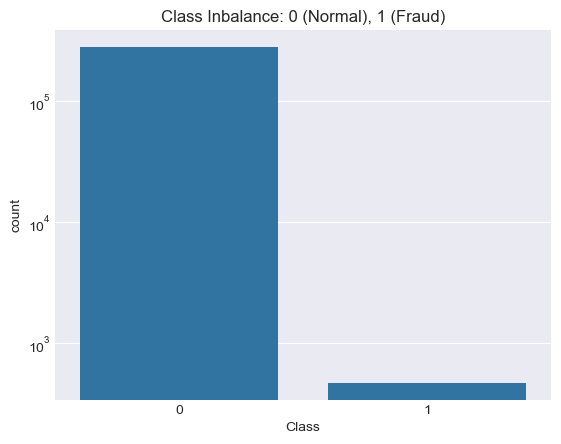

In [49]:
sns.countplot(x='Class', data=data_clean)
plt.title('Class Inbalance: 0 (Normal), 1 (Fraud)')
plt.yscale('log')
plt.show()

2. **Transaction Time**

We want to see if fraud is time-dependent (e.g., more likely to happen at night).

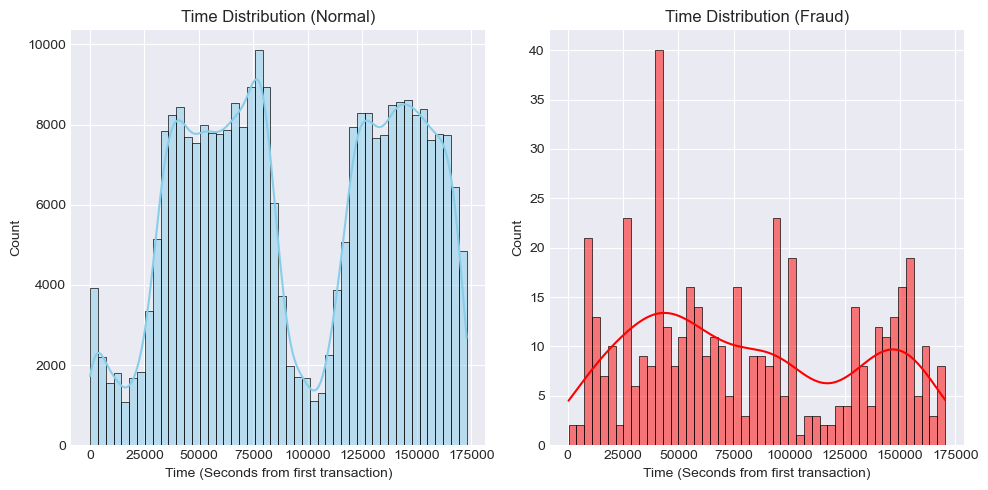

In [50]:
# Create two separate dataframes for visualization
df_fraud = data_clean[data_clean['Class'] == 1]
df_normal = data_clean[data_clean['Class'] == 0]

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
# Histogram of Time for Normal Transactions
sns.histplot(df_normal['Time'], bins=48, kde=True, color='skyblue')
plt.title('Time Distribution (Normal)')
plt.xlabel('Time (Seconds from first transaction)')

plt.subplot(1, 2, 2)
# Histogram of Time for Fraud Transactions (Look for peaks)
sns.histplot(df_fraud['Time'], bins=48, kde=True, color='red')
plt.title('Time Distribution (Fraud)')
plt.xlabel('Time (Seconds from first transaction)')
plt.tight_layout()
plt.show()

3. **Transaction Amount**

We want to compare the typical magnitude of fraudulent versus legitimate transactions.

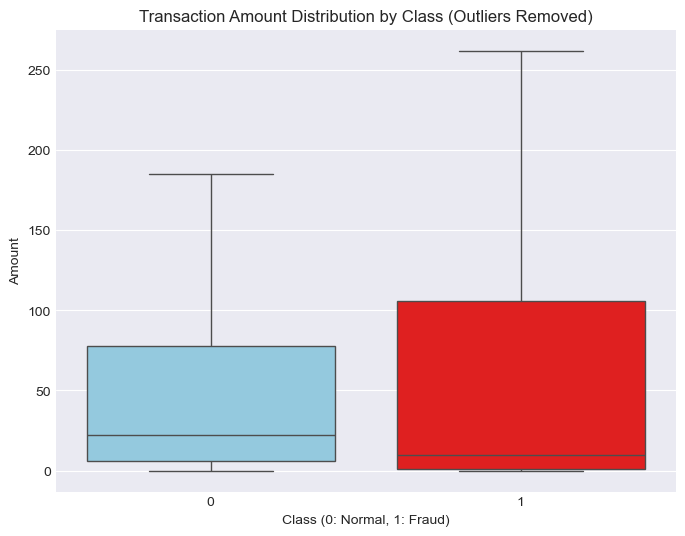

In [51]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='Class', y='Amount', data=data_clean, palette=['skyblue', 'red'], showfliers=False)
plt.title('Transaction Amount Distribution by Class (Outliers Removed)')
plt.xlabel('Class (0: Normal, 1: Fraud)')
plt.ylabel('Amount')

# Note: showfliers=False is used here because the huge outliers will skew the boxplot dramatically.
# Fraudulent transactions often cluster at lower amounts (testing the card) or highly unusual amounts.
plt.show()

4. **Correlation Check**

A quick check to ensure there are no unintended high correlations between the features, which could complicate some model types.

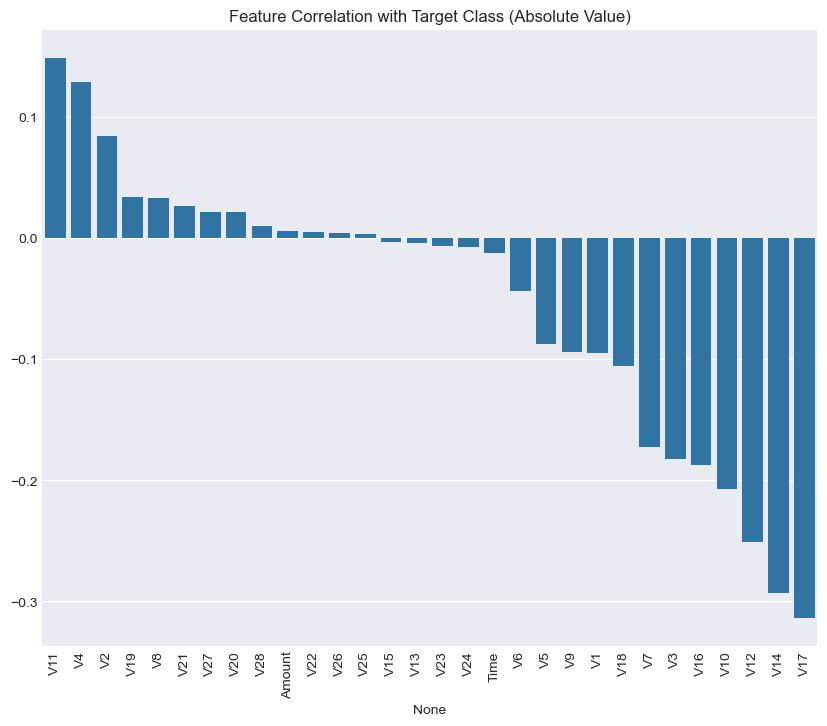

In [52]:
plt.figure(figsize=(10, 8))
# Look at correlation with the 'Class' variable specifically
correlation_matrix = data_clean.corr()
class_correlation = correlation_matrix['Class'].sort_values(ascending=False)

sns.barplot(x=class_correlation.index[1:], y=class_correlation.values[1:])
plt.title('Feature Correlation with Target Class (Absolute Value)')
plt.xticks(rotation=90)
plt.show()

Analysis of PCA Components (V-Features)
Since these features are uninterpretable, the best way to gain insight is to see which features exhibit the greatest difference in distribution between the two classes.

A. Select Discriminative Features
You should randomly select or strategically pick a few V-features (e.g., V1, V4, V10, V17) that are commonly known to be highly discriminative in fraud detection.

# **DATA PREPROCESSING**

1. Separate Features and Target

First, split your cleaned DataFrame (Data) into the feature matrix ($\mathbf{X}$) and the target vector ($\mathbf{y}$).

In [53]:
# X contains all features (Time, Amount, V1-V28)
X = data_clean.drop('Class', axis=1)

# y contains the target variable (0 or 1)
y = data_clean['Class']

2. The Crucial Step: Train/Test Split

You must split your data before scaling or any subsequent transformation. The goal is to isolate a test set that is completely untouched and unseen by any part of the training process.

We use stratify=y to ensure that the extremely rare Fraud class is represented in the same proportion in both the training and test sets.

In [60]:
# Hold out 20% of the data for final, unbiased testing
X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y # Ensures equal distribution of fraud cases in both sets
)

print(f"Train set fraud count: {y_train.sum()} ({y_train.mean()*100:.4f}%)")
print(f"Test set fraud count: {y_test.sum()} ({y_test.mean()*100:.4f}%)")

Train set fraud count: 378 (0.1665%)
Test set fraud count: 95 (0.1674%)


3. Feature Scaling (Fitting ONLY on Training Data)

The Time and Amount features are not PCA-transformed and have large, non-standard ranges. They must be scaled.

Crucial Rule: The scaling object (the StandardScaler) must be fitted only on the training data (X_train) to calculate the mean and standard deviation. It is then used to transform both the training and test data.

In [55]:
# Identify the non-PCA features that need scaling
features_to_scale = ['Time', 'Amount']

# 3a. Initialize and Fit the Scaler on TRAINING DATA
scaler = StandardScaler()
scaler.fit(X_train[features_to_scale]) # Only fit on training data!

# 3b. Transform both datasets
# Use .copy() to prevent SettingWithCopyWarning, especially with loc
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

# Apply the transformation
X_train_scaled.loc[:, features_to_scale] = scaler.transform(X_train_scaled[features_to_scale])
X_test_scaled.loc[:, features_to_scale] = scaler.transform(X_test_scaled[features_to_scale])

# Verification Check
print("\n--- Scaling Verification (X_train) ---")
print(f"Scaled Time Mean: {X_train_scaled['Time'].mean():.4f}")
print(f"Scaled Amount Std Dev: {X_train_scaled['Amount'].std():.4f}")


--- Scaling Verification (X_train) ---
Scaled Time Mean: -0.0000
Scaled Amount Std Dev: 1.0000
